# Power Spectrum

In [1]:
# import useful libraries
import numpy as np
import matplotlib.pyplot as plt
import torch 

import sys
from pathlib import Path

# set parent directory to sys.path for imports
NOTEBOOK_DIR = Path.cwd().resolve()
PARENT_DIR = NOTEBOOK_DIR.parents[2]
if str(PARENT_DIR) not in sys.path:
    sys.path.insert(0, str(PARENT_DIR))
    print(f"Parent directory added to sys.path: ...\\{PARENT_DIR.name}")
else:
    print(f"Parent directory already in sys.path: ...\\{PARENT_DIR.name}")


# set dataset directory path
DATA_TEST_PATH = PARENT_DIR / "data" / "test"
print("Dataset directory used:", f"...\\{PARENT_DIR.name}\\{DATA_TEST_PATH.relative_to(PARENT_DIR)}")

from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch

Parent directory added to sys.path: ...\STL-Dev
Dataset directory used: ...\STL-Dev\data\test


In [2]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

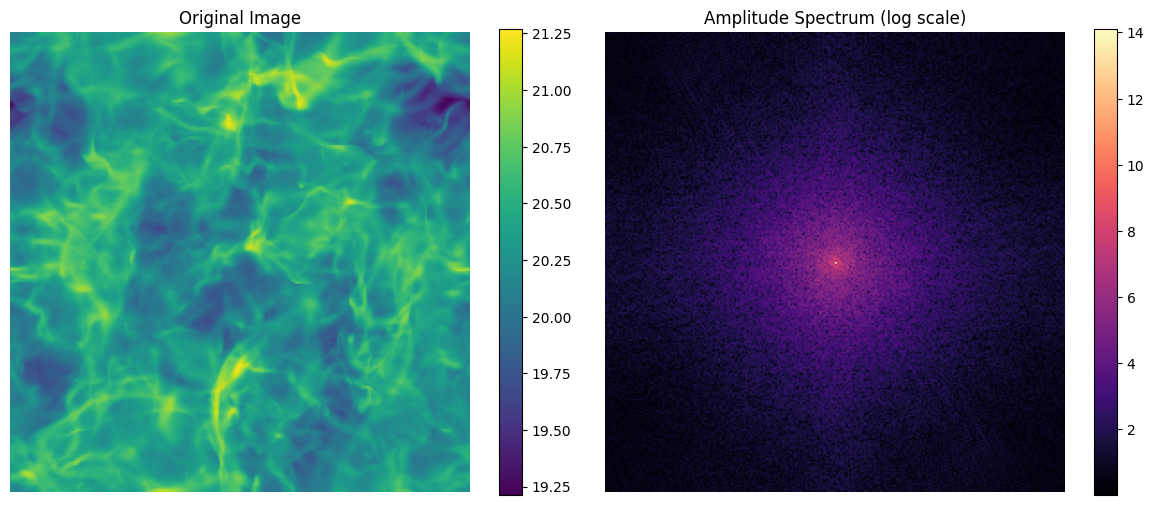

In [3]:
# Load periodic data
im = np.load(str(DATA_TEST_PATH) + "/" + "Turb_6.npy")[0]
im = torch.from_numpy(im).float()

# Compute FFT amplitude spectrum
im_fft = torch.fft.fftshift(torch.fft.fft2(im))
im_fft_amp = torch.abs(im_fft)

# Plot original data and amplitude spectrum
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(im.numpy(), cmap="viridis")
plt.axis("off")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Amplitude Spectrum (log scale)")
plt.imshow(torch.log1p(im_fft_amp).numpy(), cmap="magma")
plt.axis("off")
plt.colorbar()

plt.tight_layout()
plt.show()

In [4]:
# Instantiate FFT dataclasse
data = STL_2D_FFT_Torch(array=im, pbc=True)
data_no_pbc = STL_2D_FFT_Torch(array=im, pbc=False)

# Get PS operator
ps_op = data.get_PS_op()

In [5]:
print("Minimal frequency:", ps_op.min_freq)
print("Maximal frequency (Nyquist):", ps_op.max_freq)
print("Estimated crop borders (for each bin mask):", ps_op.crop_borders)

Minimal frequency: 0.015625
Maximal frequency (Nyquist): 0.5
Estimated crop borders (for each bin mask): tensor([17, 11, 12, 13, 13, 13, 11, 14, 16, 16, 19, 21, 23, 18, 18, 17])


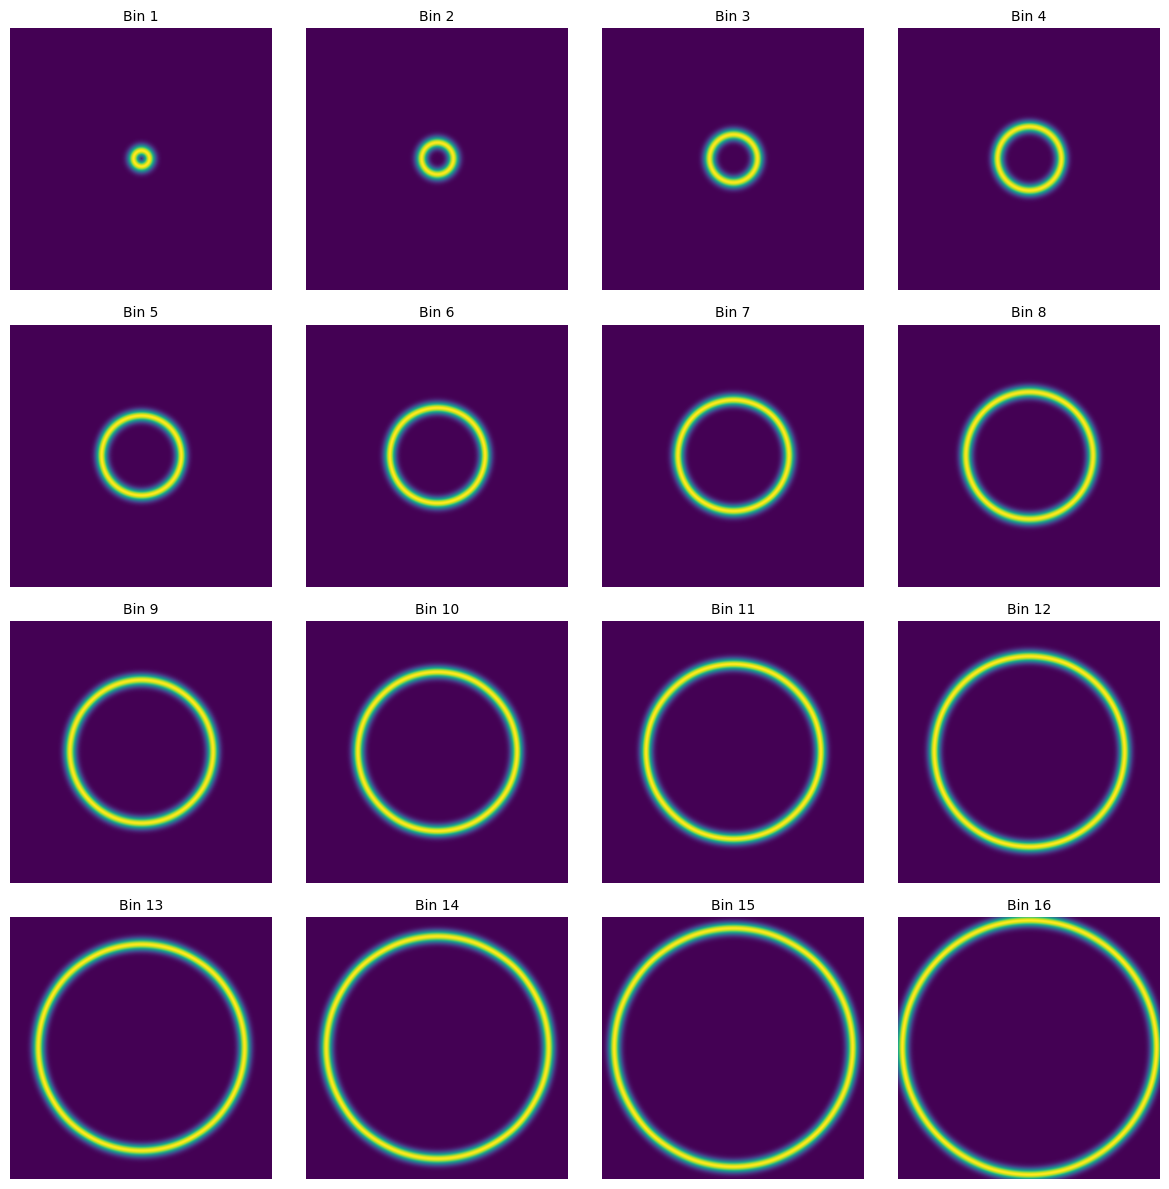

In [6]:
# Plot bin masks in fourier space (rings with gaussian radial profile)
plt.figure(figsize=(12, 12)) 

n_rows, n_cols = 4, 4       

for i in range(ps_op.bin_masks.shape[0]):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(ps_op.bin_masks[i].cpu(), cmap='viridis', origin='lower')
    plt.title(f"Bin {i+1}", fontsize=10)
    plt.axis('off')  

plt.tight_layout()
plt.show()

In [11]:
print(ps_op.bin_masks.shape)

torch.Size([16, 256, 256])


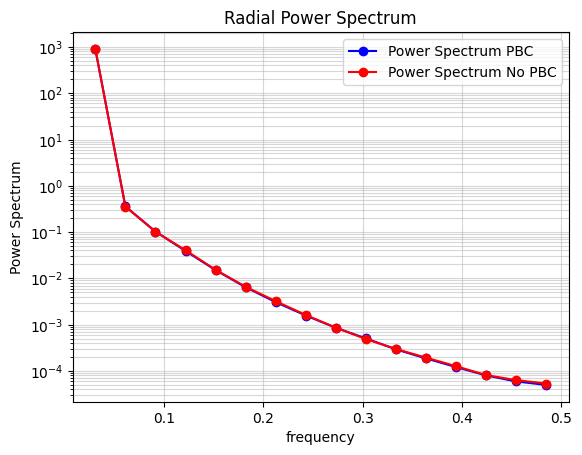

In [7]:
# Compute power spectrum for both periodic and non-periodic data
power_spectrum = ps_op.apply(data)
power_spectrum_no_pbc = ps_op.apply(data_no_pbc, get_crop_border_size_method="flexible_crop")

# Compare power spectra (should be aligned for the same periodic data, even if specified as non periodic)
ps_op.plot_PS(power_spectrum, b=0, c=0, label="Power Spectrum PBC", color="b")
ps_op.plot_PS(power_spectrum_no_pbc, b=0, c=0, label="Power Spectrum No PBC", color="r")

Great, it fits pretty well!

Let's now compare power spectrum between pbc and real non pbc data

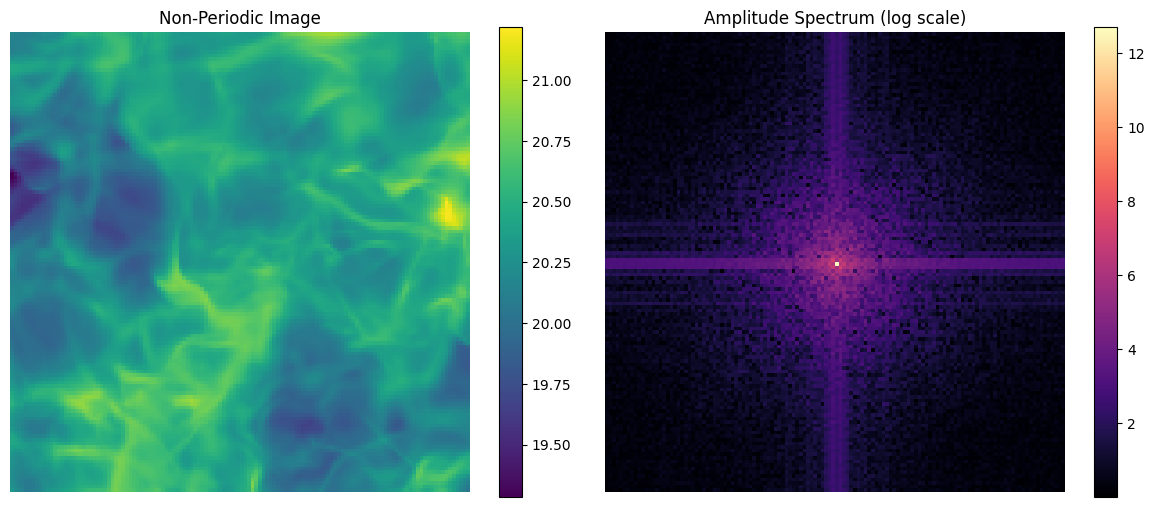

In [8]:
# Extract non periodic portion (128x128) from the original data
im_no_pbc = im[0:128, 0:128]

# Compute FFT amplitude spectrum of non periodic data
im_no_pbc_fft = torch.fft.fftshift(torch.fft.fft2(im_no_pbc))
im_no_pbc_fft_amp = torch.abs(im_no_pbc_fft)

# Plot non periodic data and its amplitude spectrum
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Non-Periodic Image")
plt.imshow(im_no_pbc.numpy(), cmap="viridis")
plt.axis("off")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title("Amplitude Spectrum (log scale)")
plt.imshow(torch.log1p(im_no_pbc_fft_amp).numpy(), cmap="magma")
plt.axis("off")
plt.colorbar()

plt.tight_layout()
plt.show()

The spectral leakage cross is strong here because we crop the original image at the level of a structure, which makes the extracted image highly non-periodic.

In [9]:
# Instantiate FFT dataclasses for both periodic and non-periodic data
data = STL_2D_FFT_Torch(array=im, pbc=True)
data_cropped_no_pbc = STL_2D_FFT_Torch(array=im_no_pbc, pbc=False)

# Get PS operator (different because build on different data shapes)
ps_op = data.get_PS_op()
ps_op_no_pbc = data_cropped_no_pbc.get_PS_op()

# Compute power spectrum for both periodic and non-periodic data
power_spectrum = ps_op.apply(data)[0, 0, :]
power_spectrum_no_pbc = ps_op_no_pbc.apply(data_cropped_no_pbc, get_crop_border_size_method="flexible_crop")[0, 0, :]

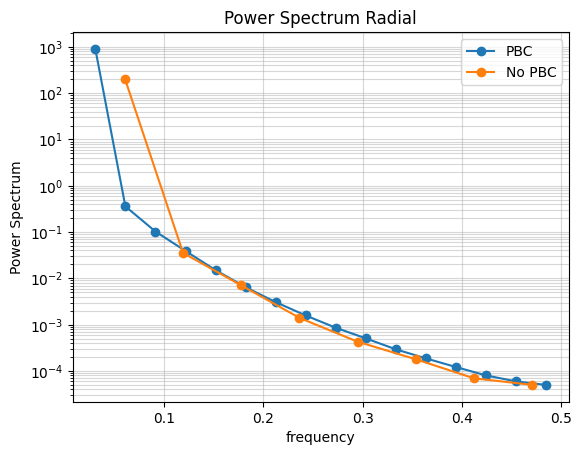

In [10]:
# Plot power spectra for both periodic and non-periodic data
plt.plot(ps_op.bin_centers, power_spectrum, "-", marker="o", label="PBC")
plt.plot(ps_op_no_pbc.bin_centers, power_spectrum_no_pbc, "-", marker="o", label="No PBC")

plt.yscale("log")
plt.xlabel("frequency")
plt.ylabel("Power Spectrum")
plt.title("Power Spectrum Radial")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

The two power spectra are estimated from images of different sizes and periodicities. They do not perfectly overlap due to sampling variance in the non-periodic cropped image, different bin intervals (and therefore not identical steps), and the cropping process.